# Multivariate Analysis

# Heatmap

In [3]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


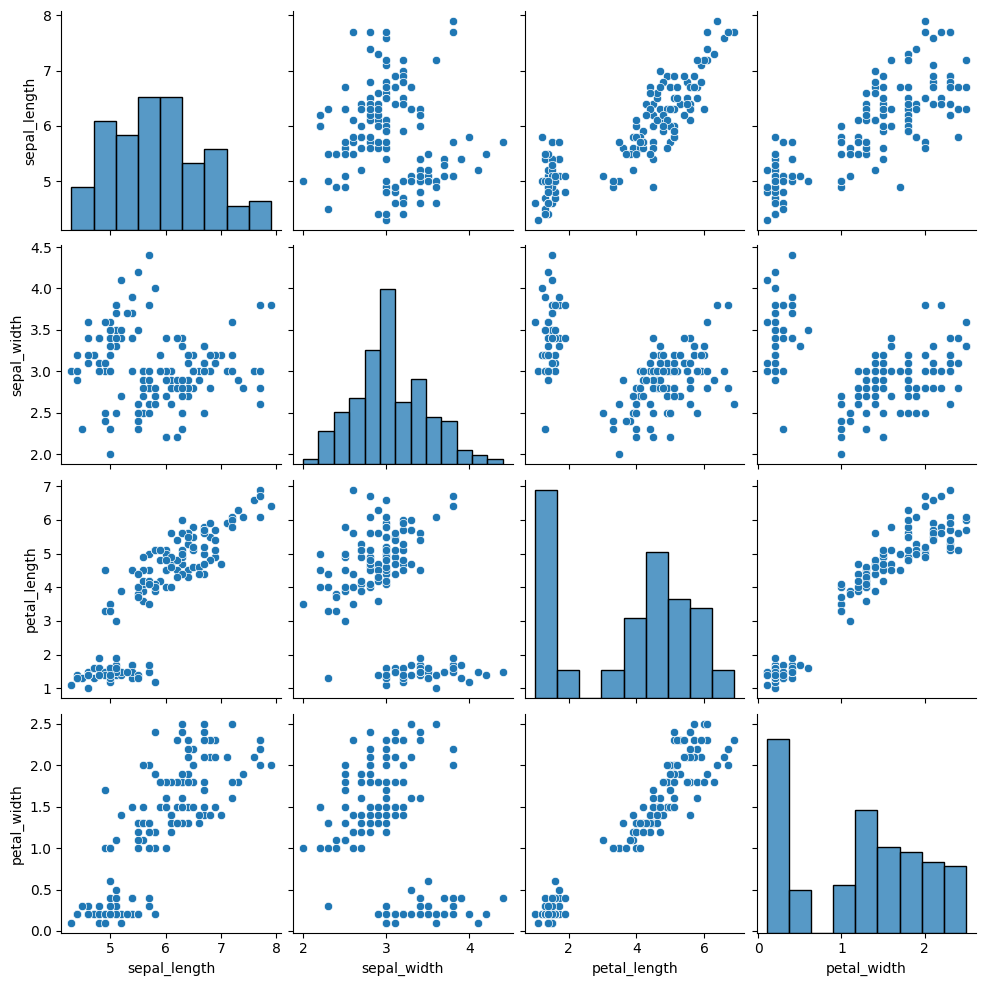

In [4]:
sns.pairplot(iris)

In [6]:
iris.describe()#.species.value_counts()
iris.sort_values("sepal_width")

,sepal_length,sepal_width,petal_length,petal_width,species
60,5.0,2.0,3.5,1.0,versicolor
62,6.0,2.2,4.0,1.0,versicolor
119,6.0,2.2,5.0,1.5,virginica
68,6.2,2.2,4.5,1.5,versicolor
41,4.5,2.3,1.3,0.3,setosa
...,...,...,...,...,...
16,5.4,3.9,1.3,0.4,setosa
14,5.8,4.0,1.2,0.2,setosa
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa


In [7]:
iris.groupby("species").mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


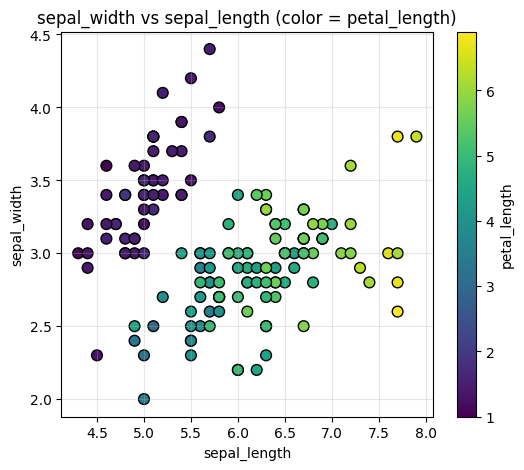

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load Iris (standard dataset)
iris = sns.load_dataset("iris")  # columns: sepal_length, sepal_width, petal_length, petal_width, species

# Choose variables
x_col = "sepal_length"
y_col = "sepal_width"
color_col = "petal_length"

x = iris[x_col].values
y = iris[y_col].values
c = iris[color_col].values

# Scatter with color mapped to the third variable
plt.figure(figsize=(6,5))
sc = plt.scatter(x, y, c=c, cmap="viridis", s=60, edgecolor='k')
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f"{y_col} vs {x_col} (color = {color_col})")
cbar = plt.colorbar(sc)
cbar.set_label(color_col)
plt.grid(alpha=0.3)
plt.show()

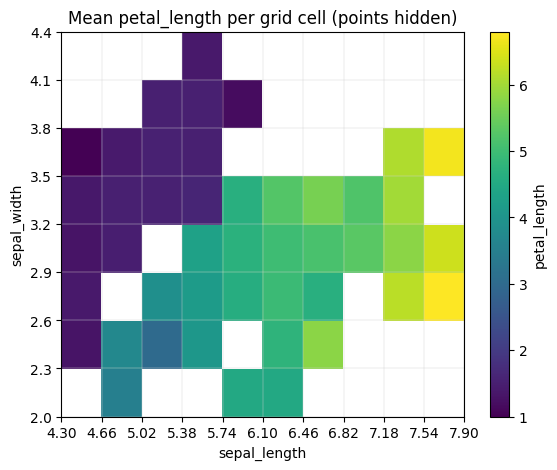

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load Iris
iris = sns.load_dataset("iris")
x_col = "sepal_length"
y_col = "sepal_width"
color_col = "petal_length"

x = iris[x_col].values
y = iris[y_col].values
c = iris[color_col].values

# Define grid resolution
nx, ny = 10, 8  # adjust for coarser/finer grid

# Compute bin edges
x_edges = np.linspace(x.min(), x.max(), nx + 1)
y_edges = np.linspace(y.min(), y.max(), ny + 1)

# Digitize points into bins (returns indices 1..nx)
ix = np.digitize(x, x_edges) - 1
iy = np.digitize(y, y_edges) - 1

# Prepare array for mean values and a mask for empty cells
mean_grid = np.full((ny, nx), np.nan)  # rows = y, cols = x

# Aggregate means per cell
for i in range(nx):
    for j in range(ny):
        mask = (ix == i) & (iy == j)
        if np.any(mask):
            mean_grid[j, i] = c[mask].mean()

# Create masked array for plotting so NaNs map to a special color
masked = np.ma.masked_invalid(mean_grid)

# Plot
fig, ax = plt.subplots(figsize=(6.5, 5))
cmap = plt.cm.viridis
cmap.set_bad(color="white")  # color for empty cells

# extent to align heatmap with original coordinate ranges
extent = [x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]]

im = ax.imshow(masked, origin="lower", extent=extent, aspect="auto", cmap=cmap)
ax.set_xlabel(x_col)
ax.set_ylabel(y_col)
ax.set_title(f"Mean {color_col} per grid cell (points hidden)")

# optional: draw grid lines between cells
ax.set_xticks(x_edges, minor=False)
ax.set_yticks(y_edges, minor=False)
ax.grid(False)  # disable default grid
# draw light cell borders
for xe in x_edges:
    ax.axvline(x=xe, color="lightgray", linewidth=0.3)
for ye in y_edges:
    ax.axhline(y=ye, color="lightgray", linewidth=0.3)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(color_col)
plt.show()

This script builds and plots a 2D binned heatmap of the mean petal_length across a rectangular grid in the sepal_length × sepal_width plane. Step-by-step:

- Imports seaborn, matplotlib, numpy, and pandas.
- Loads the iris dataset via seaborn.
- Selects sepal_length as x, sepal_width as y, and petal_length as the value to aggregate (c).
- Defines a regular grid resolution (nx columns, ny rows) and computes the bin edges for x and y using linspace.
- Digitizes each sample’s x and y values into bin indices (ix, iy).
- Creates a ny × nx array mean_grid filled with NaN, then loops over every grid cell and, for points that fall into that cell, computes the mean of c and stores it in the corresponding cell. Empty cells remain NaN.
- Converts mean_grid to a masked array masking invalid (NaN) cells so they can be drawn with a special color.
- Sets up a matplotlib figure, uses the viridis colormap and sets the “bad” color (masked cells) to white.
- Plots the masked mean grid with imshow, using extent based on the bin edges so the heatmap aligns with the original x/y coordinate ranges; origin="lower" makes the first row correspond to the lowest y.
- Labels axes and title, draws light cell borders by plotting vertical/horizontal lines at the bin edges, and disables the default grid.
- Adds a colorbar labeled with the aggregated column name and shows the figure.

Result: a heatmap where each cell shows the mean petal_length of iris samples whose sepal_length/sepal_width fall inside that cell; cells with no points are white.

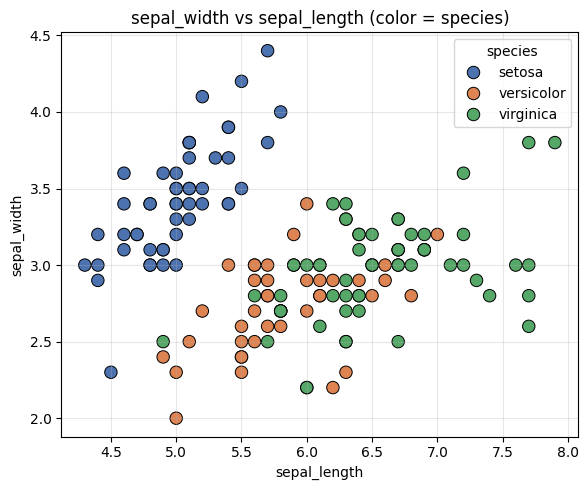

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load Iris
iris = sns.load_dataset("iris")

# Variables for axes
x_col = "sepal_length"
y_col = "sepal_width"

plt.figure(figsize=(6,5))
# Scatter with color = species (categorical); use seaborn palette for clear colors
sns.scatterplot(data=iris, x=x_col, y=y_col, hue="species", palette="deep", s=80, edgecolor='k')
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f"{y_col} vs {x_col} (color = species)")
plt.grid(alpha=0.3)
plt.legend(title="species")
plt.tight_layout()
plt.show()

# Correlogram

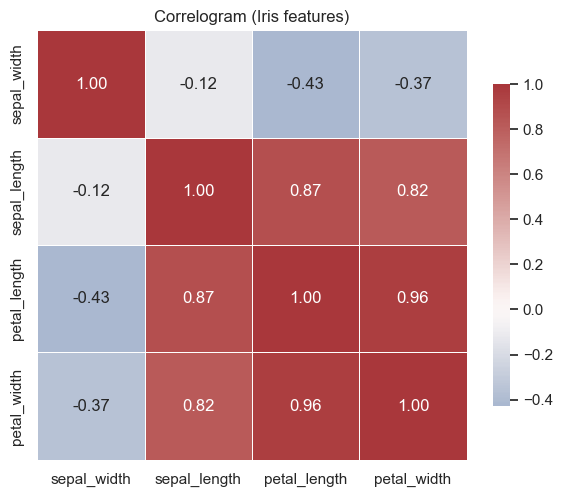

In [50]:
# Correlogram (correlation heatmap) for a standard dataset (Iris)
# Requires: numpy, pandas, seaborn, matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load Iris dataset (4 numeric features)
iris = sns.load_dataset("iris")
numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
df = iris[numeric_cols]

# Compute correlation matrix
corr = df.corr()

# Optional: reorder variables by hierarchical clustering for a nicer layout
try:
    # seaborn.clustermap can compute a clustered order; we extract its ordering
    cg = sns.clustermap(corr, metric="euclidean", method="average", cmap="vlag", center=0)
    order = cg.dendrogram_col.reordered_ind
    plt.close(cg.fig)  # close clustermap figure; we'll draw a nicer heatmap below with the order
    ordered_cols = [numeric_cols[i] for i in order]
    corr = corr.loc[ordered_cols, ordered_cols]
except Exception:
    ordered_cols = numeric_cols  # fallback, no reordering

# Plot correlogram
plt.figure(figsize=(6,5))
ax = sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True,
                 linewidths=0.5, cbar_kws={"shrink": .75})
ax.set_title("Correlogram (Iris features)")
plt.tight_layout()
plt.show()

# Multivariate linear regression using sklearn

OLS regression predicting petal_length from sepal_length, sepal_width, petal_width
Number of observations: 150, predictors (including intercept): 4

Coefficient estimates and approximate standard errors (OLS):
    variable         coef      std.err
   intercept    -0.262711     0.297406
sepal_length     0.729138     0.058319
 sepal_width    -0.646012     0.068497
 petal_width     1.446793     0.067611

    variable          t    p-value
   intercept    -0.8833     0.3785
sepal_length    12.5025          0
 sepal_width    -9.4312   2.22e-16
 petal_width    21.3987          0
Correlation: [[1.         0.98387589]
 [0.98387589 1.        ]]


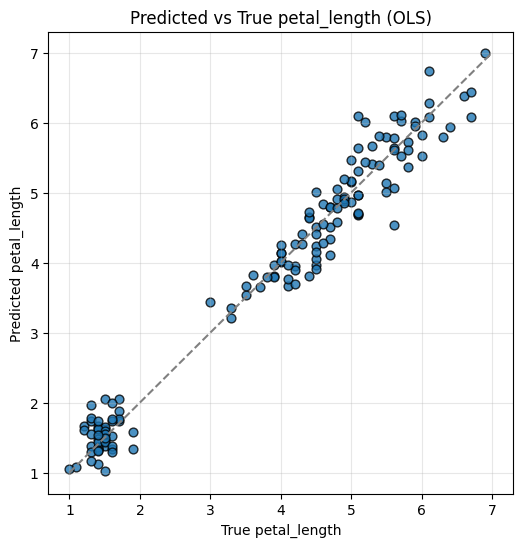

In [18]:
# Multivariate linear regression (sklearn) predicting petal_length from the other Iris numeric features.
# Prints coefficients and their standard errors (approximate via OLS formulas),
# and plots predicted vs true petal_length.
#
# Requires: numpy, pandas, matplotlib, seaborn, scikit-learn, statsmodels (for robust SEs if desired).
# This uses ordinary least squares closed-form formulas for standard errors for clarity.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load data
iris = sns.load_dataset("iris")
# Features and target
X = iris[["sepal_length", "sepal_width", "petal_width"]].values  # predictors
y = iris["petal_length"].values  # target

# Optional: add an intercept column for manual OLS SE computation
# We'll let sklearn fit intercept, but for SE formulas we construct the design matrix with a column of ones.
X_design = np.column_stack([np.ones(X.shape[0]), X])  # shape (n, p+1), first column = intercept

# Fit sklearn LinearRegression (fits intercept by default)
model = LinearRegression(fit_intercept=True)
model.fit(X, y)
y_pred = model.predict(X)

# Extract coefficients: intercept and coefs
intercept = model.intercept_
coefs = model.coef_  # order aligned with X columns
feature_names = ["intercept"] + ["sepal_length", "sepal_width", "petal_width"]

# Compute standard errors of coefficients using OLS formulas
# Residual sum of squares and estimate of sigma^2
n, p = X_design.shape  # p includes intercept column
residuals = y - y_pred
rss = np.sum(residuals**2)
df_resid = n - p
sigma2_hat = rss / df_resid  # estimated variance of residuals

# (X'X)^{-1}
XtX_inv = np.linalg.inv(X_design.T @ X_design)
# Standard errors: sqrt(diag(sigma2_hat * (X'X)^{-1}))
se = np.sqrt(np.diag(sigma2_hat * XtX_inv))

# Collect coefficient vector in same order
coef_vector = np.concatenate([[intercept], coefs])

# Print results
print("OLS regression predicting petal_length from sepal_length, sepal_width, petal_width")
print(f"Number of observations: {n}, predictors (including intercept): {p}")
print()
print("Coefficient estimates and approximate standard errors (OLS):")
print("{:>12} {:>12} {:>12}".format("variable", "coef", "std.err"))
for name, c, s in zip(feature_names, coef_vector, se):
    print(f"{name:>12} {c:12.6f} {s:12.6f}")

# Optionally compute t-stats and two-sided p-values (approx)
t_stats = coef_vector / se
from scipy import stats
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=df_resid))
print()
print("{:>12} {:>10} {:>10}".format("variable", "t", "p-value"))
for name, t, pv in zip(feature_names, t_stats, p_values):
    print(f"{name:>12} {t:10.4f} {pv:10.4g}")

# Plot predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, s=40, alpha=0.8, edgecolor='k')
minv = min(y.min(), y_pred.min())
maxv = max(y.max(), y_pred.max())
plt.plot([minv, maxv], [minv, maxv], color='gray', linestyle='--')
plt.xlabel("True petal_length")
plt.ylabel("Predicted petal_length")
plt.title("Predicted vs True petal_length (OLS)")
plt.grid(alpha=0.3)
print("Correlation:", np.corrcoef(y, y_pred))
plt.show()

# Multivariate linear regression using statsmodels

                            OLS Regression Results                            
Dep. Variable:           petal_length   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     1473.
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          6.98e-109
Time:                        16:18:53   Log-Likelihood:                -39.408
No. Observations:                 150   AIC:                             86.82
Df Residuals:                     146   BIC:                             98.86
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.2627      0.297     -0.883   

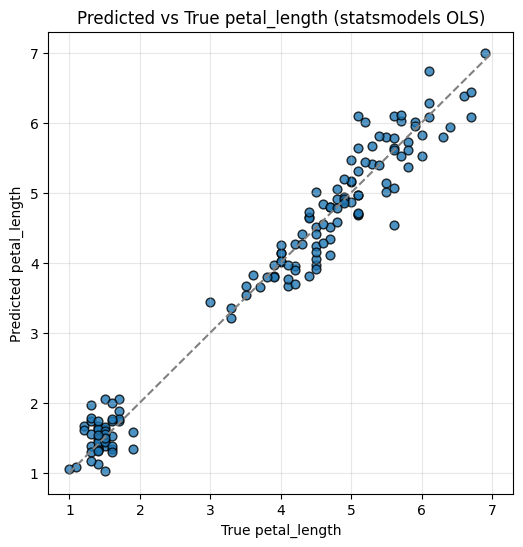

In [32]:
# OLS regression using statsmodels: predict petal_length from sepal_length, sepal_width, petal_width
# This prints the full statsmodels summary (includes coefficients, std errors, t-stats, p-values, R^2, etc.)
# and also plots predicted vs true petal_length.
#
# Requires: numpy, pandas, matplotlib, seaborn, statsmodels
# If statsmodels is not installed: pip install statsmodels
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Load data
iris = sns.load_dataset("iris")

# Define predictors and target
predictors = ["sepal_length", "sepal_width", "petal_width"]
y = iris["petal_length"]
X = iris[predictors]

# Add constant (intercept) term
X_sm = sm.add_constant(X)  # adds a column named 'const'

# Fit OLS model
model = sm.OLS(y, X_sm)
results = model.fit()

# Print the summary table
print(results.summary())

# Extract fitted values to plot predicted vs true
y_pred = results.fittedvalues

# Plot predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, s=40, alpha=0.8, edgecolor='k')
minv = min(y.min(), y_pred.min())
maxv = max(y.max(), y_pred.max())
plt.plot([minv, maxv], [minv, maxv], color='gray', linestyle='--')
plt.xlabel("True petal_length")
plt.ylabel("Predicted petal_length")
plt.title("Predicted vs True petal_length (statsmodels OLS)")
plt.grid(alpha=0.3)
plt.show()

# PCA

Principal component vectors (each row is a unit vector; columns are features):

     sepal_length  sepal_width  petal_length  petal_width
PC1      0.521066    -0.269347      0.580413     0.564857
PC2      0.377418     0.923296      0.024492     0.066942
PC3      0.719566    -0.244382     -0.142126    -0.634273
PC4     -0.261286     0.123510      0.801449    -0.523597

Row norms (should be 1.0): [1. 1. 1. 1.]


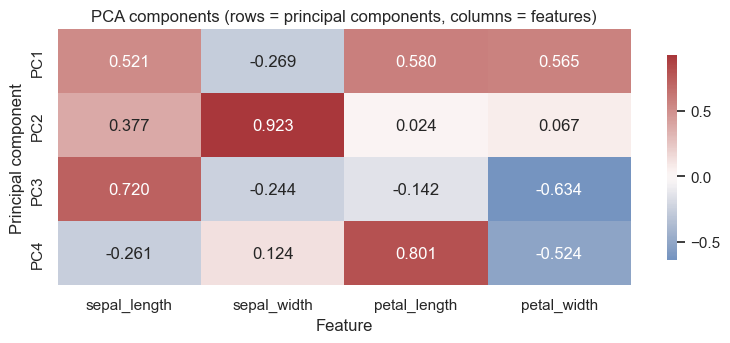


Explained variance ratio (fraction of variance explained by each PC):
 PC1: 0.7296
 PC2: 0.2285
 PC3: 0.0367
 PC4: 0.0052


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import sklearn.preprocessing as prep

# Load iris and select numeric features
iris = sns.load_dataset("iris")
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X = iris[features].values

# Standardize features (zero mean, unit variance) — common preprocessing for PCA
scaler = prep.StandardScaler()
Xz = scaler.fit_transform(X)

# Fit PCA (keep all 4 components)
pca = PCA(n_components=4)
pca.fit(Xz)

# Components_: array, shape (n_components, n_features)
# Each row is a principal component (unit vector) in feature space
components = pca.components_  # rows are components, columns align with features

# Print numeric matrix: rows = PC1..PC4, columns = features
pc_names = [f"PC{i+1}" for i in range(components.shape[0])]
df_comp = pd.DataFrame(components, index=pc_names, columns=features)
print("Principal component vectors (each row is a unit vector; columns are features):\n")
print(df_comp.round(6))

# Confirm each row has unit length (within numerical precision)
row_norms = np.linalg.norm(components, axis=1)
print("\nRow norms (should be 1.0):", np.round(row_norms, 12))

# Plot as a heatmap so signs and magnitudes are visible
plt.figure(figsize=(8, 3.6))
sns.heatmap(df_comp, annot=True, fmt=".3f", cmap="vlag", center=0, cbar_kws={"shrink": 0.8})
plt.title("PCA components (rows = principal components, columns = features)")
plt.xlabel("Feature")
plt.ylabel("Principal component")
plt.tight_layout()
plt.show()

# Also print explained variance ratio for context
print("\nExplained variance ratio (fraction of variance explained by each PC):")
for i, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f" PC{i}: {ratio:.4f}")

In [20]:
0.521 * 0.377 + (-0.269 * 0.923) + (0.580 * 0.024) + (0.565 * 0.067)

-9.500000000002562e-05

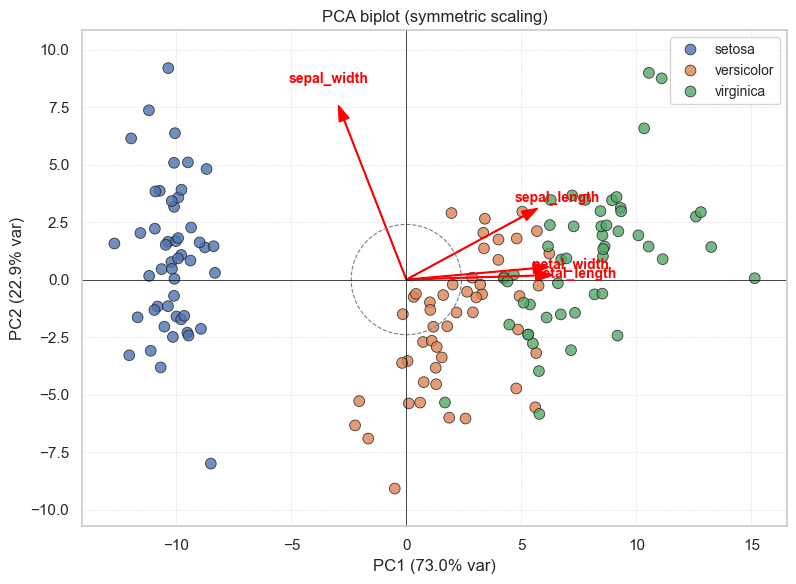


Numeric loadings (symmetric scaling) used for arrows (before display scaling):
                 PC1     PC2
sepal_length  2.3834  1.2915
sepal_width  -1.2320  3.1594
petal_length  2.6549  0.0838
petal_width   2.5838  0.2291

Explained variance ratio (PC1, PC2):
[0.7296 0.2285]


In [41]:
# PCA biplot (symmetric scaling) for Iris PCA already computed above.
# Assumes you have Xz (standardized data) and fitted pca (sklearn.PCA) as in your snippet.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt

# Compute scores (projections) and loadings for the biplot
# Using symmetric scaling: scores = U * sqrt(S), loadings = V^T * sqrt(S)
# For sklearn PCA, components_ = V (rows are PCs), singular values s = sqrt( (n-1) * explained_variance )
n_samples = Xz.shape[0]
# singular values (length = n_components)
singular_values = np.sqrt(pca.explained_variance_ * (n_samples - 1))
# Scores in sklearn: components_ are V (rows), and transform gives Xz @ V.T = U Sigma
# Obtain the full scores (Xz projected onto PC axes)
scores = pca.transform(Xz)  # shape (n_samples, n_components)

# Symmetric scaling:
# scale scores by sqrt(singular_values)
# scale loadings (components_.T columns) by sqrt(singular_values)
sv_sqrt = np.sqrt(singular_values)
# Avoid broadcasting pitfalls: make (n_components,) -> (1,n_components)
scores_sym = scores[:, :2] * sv_sqrt[:2]  # n x 2
loadings = pca.components_.T[:, :2]      # shape (n_features, 2)
loadings_sym = loadings * sv_sqrt[:2]    # n_features x 2

# Prepare plot
feature_names = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
species = iris["species"] if "species" in iris.columns else None

plt.figure(figsize=(8, 6))
ax = plt.gca()

# Scatter the scores (observations) on PC1 vs PC2
# color by species if available
if species is not None:
    sns.scatterplot(x=scores_sym[:, 0], y=scores_sym[:, 1], hue=species, palette="deep", s=60, ax=ax, edgecolor='k', alpha=0.8)
else:
    ax.scatter(scores_sym[:, 0], scores_sym[:, 1], color='C0', s=50, alpha=0.7, edgecolor='k')

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("PCA biplot (symmetric scaling)")

# Plot variable loadings as arrows
# Determine a reasonable arrow scaling for display: scale so arrows fit nicely relative to scores
# We'll compute a factor so the longest arrow is, say, 50% of the max score range
score_max = np.max(np.abs(scores_sym))  # magnitude scale of scores
loading_max = np.max(np.abs(loadings_sym))
if loading_max == 0:
    arrow_scale = 1.0
else:
    arrow_scale = 0.5 * score_max / loading_max

for i, feature in enumerate(feature_names):
    x_load = loadings_sym[i, 0] * arrow_scale
    y_load = loadings_sym[i, 1] * arrow_scale
    ax.arrow(0, 0, x_load, y_load, color='red', width=0.002*score_max, head_width=0.03*score_max, length_includes_head=True)
    ax.text(x_load * 1.15, y_load * 1.15, feature, color='red', ha='center', va='center', fontsize=10, fontweight='bold')

# Optional: draw a unit circle in loading space (after scaling) for reference
theta = np.linspace(0, 2*np.pi, 200)
circle_x = np.cos(theta) * arrow_scale
circle_y = np.sin(theta) * arrow_scale
ax.plot(circle_x, circle_y, color='gray', linestyle='--', linewidth=0.8)

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.grid(True, linestyle=':', linewidth=0.5)
ax.set_aspect('equal', adjustable='datalim')
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()

# Print numeric loadings used for arrows (symmetric scaled)
print("\nNumeric loadings (symmetric scaling) used for arrows (before display scaling):")
load_df = pd.DataFrame(loadings_sym, index=feature_names, columns=["PC1", "PC2"])
print(load_df.round(4))

print("\nExplained variance ratio (PC1, PC2):")
print(np.round(pca.explained_variance_ratio_[:2], 4))

PCA components (rows = PCs, columns = predictors):
     sepal_length  petal_length  petal_width
PC1        0.5596        0.5915       0.5805
PC2        0.8127       -0.2546      -0.5241
PC3       -0.1622        0.7651      -0.6232

Explained variance ratio (PC1..PC3): [0.9232 0.0665 0.0103]

Model: PC1 only
 intercept:  3.057333
      PC1: -0.083399
 Pearson r = 0.3195, p = 6.74e-05

Model: PC1 + PC2
 intercept:  3.057333
      PC1: -0.083399
      PC2:  0.447506
 Pearson r = 0.5601, p = 9.2e-14

Model: PC1 + PC2 + PC3
 intercept:  3.057333
      PC1: -0.083399
      PC2:  0.447506
      PC3: -1.134291
 Pearson r = 0.7239, p = 1.25e-25



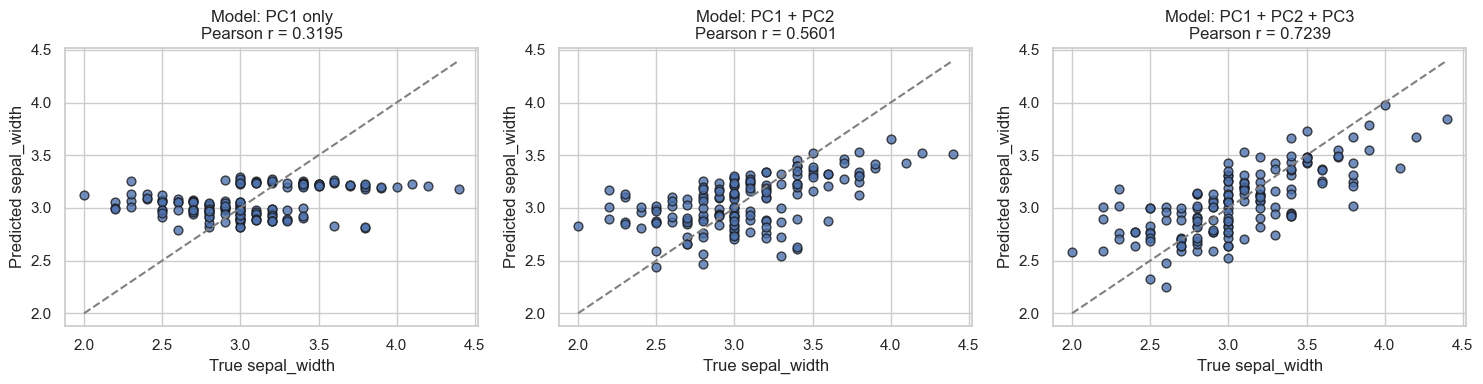

Summary correlations (true vs predicted):
 Model: PC1 only                 r = 0.3195
 Model: PC1 + PC2                r = 0.5601
 Model: PC1 + PC2 + PC3          r = 0.7239


In [81]:
# PCA on predictors, then regress petal_length on increasing numbers of PCs:
# 1) PC1 only
# 2) PC1 + PC2
# 3) PC1 + PC2 + PC3
#
# PCA is computed on the predictors only (sepal_length, sepal_width, petal_width).
# For each model we print coefficients, plot predicted vs true petal_length, and show Pearson r.
#
# Requirements: numpy, pandas, matplotlib, seaborn, scikit-learn, scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

sns.set(style="whitegrid")
np.random.seed(0)

# Load data
iris = sns.load_dataset("iris")

# Predictors (exclude petal_length) and target
predictor_cols = ["sepal_length", "petal_length", "petal_width"]
target_col = "sepal_width"

X = iris[predictor_cols].values
y = iris[target_col].values

# Standardize predictors before PCA
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

# PCA on predictors, keep 3 components
pca = PCA(n_components=3)
PCs = pca.fit_transform(Xz)  # shape (n_samples, 3)

# Print PCA components and explained variance for context
comp_df = pd.DataFrame(pca.components_, index=["PC1","PC2","PC3"], columns=predictor_cols)
print("PCA components (rows = PCs, columns = predictors):")
print(comp_df.round(4))
print("\nExplained variance ratio (PC1..PC3):", np.round(pca.explained_variance_ratio_, 4))
print()

# Helper to fit regression on selected PCs and plot
def fit_and_plot(pc_indices, ax, title):
    X_model = PCs[:, pc_indices]
    model = LinearRegression(fit_intercept=True)
    model.fit(X_model, y)
    y_pred = model.predict(X_model)
    # Coefficients: intercept then coeffs in order
    coef_names = ["intercept"] + [f"PC{idx+1}" for idx in pc_indices]
    coef_values = np.concatenate([[model.intercept_], model.coef_])
    # Print coefficients
    print(title)
    for name, val in zip(coef_names, coef_values):
        print(f" {name:>8s}: {val: .6f}")
    # Pearson correlation
    r, pval = pearsonr(y, y_pred)
    # Plot predicted vs true
    ax.scatter(y, y_pred, s=40, alpha=0.8, edgecolor='k')
    mn = min(y.min(), y_pred.min())
    mx = max(y.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], color='gray', linestyle='--')
    ax.set_xlabel(f"True {target_col}")
    ax.set_ylabel(f"Predicted {target_col}")
    ax.set_title(f"{title}\nPearson r = {r:.4f}")
    ax.grid(True)
    print(f" Pearson r = {r:.4f}, p = {pval:.3g}\n")
    return model, r

# Create plots for three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ([0], "Model: PC1 only"),
    ([0, 1], "Model: PC1 + PC2"),
    ([0, 1, 2], "Model: PC1 + PC2 + PC3"),
]

results = []
for (indices, title), ax in zip(models, axes):
    m, r = fit_and_plot(indices, ax, title)
    results.append((indices, title, r))

plt.tight_layout()
plt.show()

# Summary table of correlations
print("Summary correlations (true vs predicted):")
for indices, title, r in results:
    print(f" {title:30s}  r = {r:.4f}")

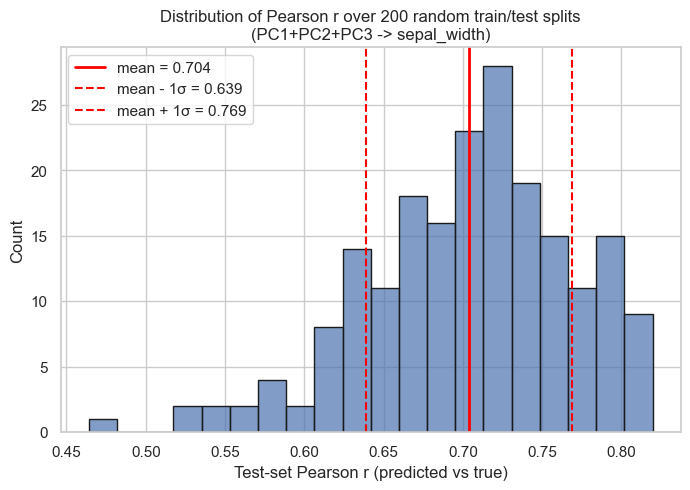

n_repeats = 200, test_size = 0.3
Mean Pearson r = 0.7039
Std  Pearson r = 0.0649
Median Pearson r = 0.7119
Min = 0.4642, Max = 0.8197


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

sns.set(style="whitegrid")
np.random.seed(0)

# Data setup: predictors and target
import seaborn as sns
iris = sns.load_dataset("iris")
predictor_cols = ["sepal_length", "petal_length", "petal_width"]
target_col = "sepal_width"

X = iris[predictor_cols].values
y = iris[target_col].values

# Standardize predictors and compute PCs
scaler = StandardScaler()
Xz = scaler.fit_transform(X)
pca = PCA(n_components=3)
PCs = pca.fit_transform(Xz)  # n x 3

# Choose which PCs to use for the model
pc_indices = [0, 1, 2]  # PC1 + PC2 + PC3
X_all = PCs[:, pc_indices]

# Repeated random train/test experiments
n_repeats = 200
test_size = 0.3
random_state = 0

r_values = []
for i in range(n_repeats):
    # use a different seed each repeat for randomness
    rs = None if random_state is None else (random_state + i)
    X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=test_size, random_state=rs, shuffle=True)
    model = LinearRegression().fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r, _ = pearsonr(y_test, y_pred)
    r_values.append(r)

r_values = np.array(r_values)
mean_r = r_values.mean()
std_r = r_values.std(ddof=1)
median_r = np.median(r_values)

# Plot histogram with mean and +/- 1 std lines
plt.figure(figsize=(8,5))
sns.histplot(r_values, bins=20, kde=False, color='C0', edgecolor='k', alpha=0.7)
plt.axvline(mean_r, color='red', linestyle='-', linewidth=2, label=f"mean = {mean_r:.3f}")
plt.axvline(mean_r - std_r, color='red', linestyle='--', linewidth=1.5, label=f"mean - 1σ = {mean_r - std_r:.3f}")
plt.axvline(mean_r + std_r, color='red', linestyle='--', linewidth=1.5, label=f"mean + 1σ = {mean_r + std_r:.3f}")
plt.xlabel("Test-set Pearson r (predicted vs true)")
plt.ylabel("Count")
plt.title(f"Distribution of Pearson r over {n_repeats} random train/test splits\n(PC1+PC2+PC3 -> {target_col})")
plt.legend()
plt.show()

# Print summary numbers
print(f"n_repeats = {n_repeats}, test_size = {test_size}")
print(f"Mean Pearson r = {mean_r:.4f}")
print(f"Std  Pearson r = {std_r:.4f}")
print(f"Median Pearson r = {median_r:.4f}")
print(f"Min = {r_values.min():.4f}, Max = {r_values.max():.4f}")

# t-SNE (t-distributed Stochastic Neighbor Embedding)

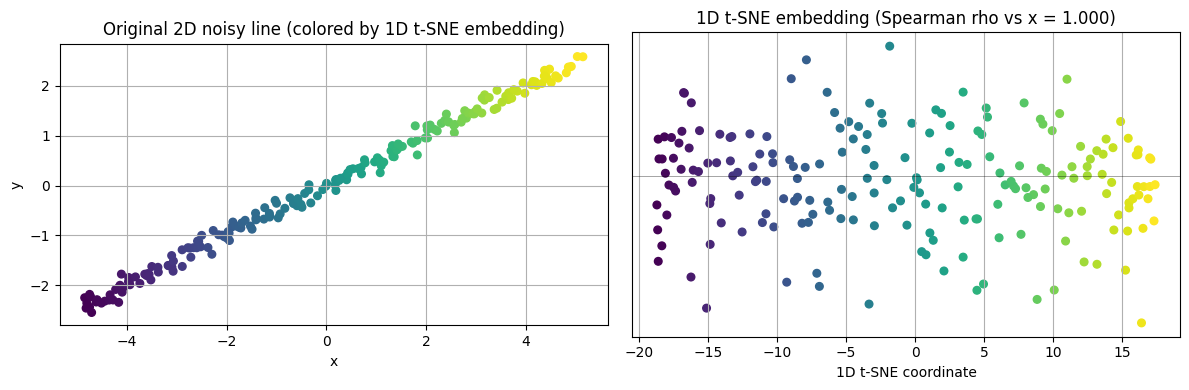

Spearman rank correlation between original x and 1D embedding: rho = 0.9996, p = 1.24e-306 (y value is meaningless jitter)


In [5]:
# t-SNE mapping from 2D -> 1D: simple line case
# - generate noisy points along a line in 2D
# - run t-SNE with n_components=1
# - plot original 2D scatter and the 1D embedding (points along a horizontal axis),
#   coloring points by their 1D coordinate to show neighborhood preservation.
#
# Requirements: numpy, matplotlib, scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.stats import spearmanr

np.random.seed(0)

# Generate noisy line data in 2D: y = 0.5 * x with small perpendicular noise
n = 200
x_vals = np.linspace(-5, 5, n)
line_points = np.column_stack([x_vals, 0.5 * x_vals])
noise_scale = 0.1
X = line_points + noise_scale * np.random.randn(n, 2)

# Run t-SNE to 1D
tsne = TSNE(n_components=1, perplexity=30, max_iter=1000, random_state=0, init='pca')
z = tsne.fit_transform(X).flatten()  # 1D embedding

# Normalize z to [0,1] for color mapping and plotting order
z_min, z_max = z.min(), z.max()
z_norm = (z - z_min) / (z_max - z_min + 1e-12)

# Measure monotonic correspondence between original x coordinate and embedded coordinate
rho, pval = spearmanr(x_vals, z)  # Spearman rank correlation: 1.0 means perfect order preservation

# Plot original 2D data colored by z; and the 1D embedding as points on a horizontal line
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(X[:, 0], X[:, 1], c=z_norm, cmap='viridis', s=30)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Original 2D noisy line (colored by 1D t-SNE embedding)')
ax1.grid(True)
ax1.set_aspect('equal', adjustable='box')

# 1D embedding along horizontal axis at y=0; jitter vertically for visibility
y_jitter = 0.03 * (np.random.randn(n))
ax2.scatter(z, y_jitter, c=z_norm, cmap='viridis', s=30)
ax2.axhline(0, color='k', linewidth=0.5, alpha=0.5)
ax2.set_yticks([])
ax2.set_xlabel('1D t-SNE coordinate')
ax2.set_title(f'1D t-SNE embedding (Spearman rho vs x = {rho:.3f})')
ax2.grid(True, axis='x')

plt.tight_layout()
plt.show()

print(f"Spearman rank correlation between original x and 1D embedding: rho = {rho:.4f}, p = {pval:.3g} (y value is meaningless jitter)")

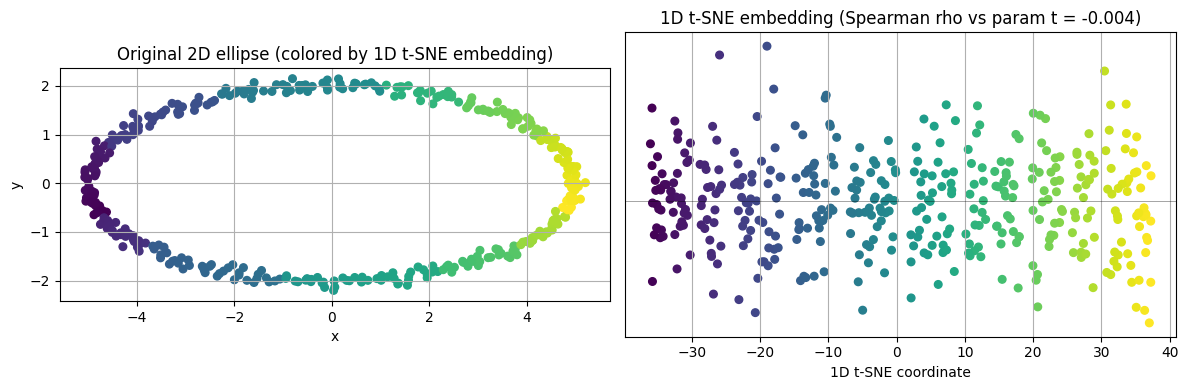

Spearman rank correlation between parameter t (ellipse angle) and 1D embedding: rho = -0.0038, p = 0.939


In [7]:
# t-SNE mapping from 2D -> 1D: oval (ellipse) case
# - generate points around an ellipse in 2D (closed curve)
# - run t-SNE with n_components=1
# - plot original 2D scatter and the 1D embedding (points along a horizontal axis),
#   coloring points by their 1D coordinate to show neighborhood preservation / unfolding.
#
# Requirements: numpy, matplotlib, scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.stats import spearmanr

np.random.seed(2)

# Generate ellipse points (parametric): x = a*cos(t), y = b*sin(t), plus small radial noise
n = 400
t = np.linspace(0, 2 * np.pi, n, endpoint=False)
a, b = 5.0, 2.0  # major/minor radii
X_circle = np.column_stack([a * np.cos(t), b * np.sin(t)])
noise_radial = 0.08
# Add small noise perpendicular to the ellipse (radial jitter)
norms = np.linalg.norm(X_circle, axis=1, keepdims=True)
X = X_circle + noise_radial * np.random.randn(n, 2)

# Run t-SNE to 1D
tsne = TSNE(n_components=1, perplexity=30, max_iter=1000, random_state=0, init='pca')
z = tsne.fit_transform(X).flatten()

# Normalize z to [0,1] for color mapping
z_min, z_max = z.min(), z.max()
z_norm = (z - z_min) / (z_max - z_min + 1e-12)

# Measure how well the circular parameter order correlates with embedded order
# Use circular-to-linear rank correlation: we compare parameter t (unwrap) with z ranks via Spearman.
rho, pval = spearmanr(t, z)

# Plot original 2D ellipse colored by z and the 1D embedding
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(X[:, 0], X[:, 1], c=z_norm, cmap='viridis', s=30)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Original 2D ellipse (colored by 1D t-SNE embedding)')
ax1.grid(True)
ax1.set_aspect('equal', adjustable='box')

# 1D embedding along horizontal axis at y=0; add a tiny vertical jitter for visibility
y_jitter = 0.01 * np.random.randn(n)
ax2.scatter(z, y_jitter, c=z_norm, cmap='viridis', s=30)
ax2.axhline(0, color='k', linewidth=0.5, alpha=0.5)
ax2.set_yticks([])
ax2.set_xlabel('1D t-SNE coordinate')
ax2.set_title(f'1D t-SNE embedding (Spearman rho vs param t = {rho:.3f})')
ax2.grid(True, axis='x')

plt.tight_layout()
plt.show()

print(f"Spearman rank correlation between parameter t (ellipse angle) and 1D embedding: rho = {rho:.4f}, p = {pval:.3g}")

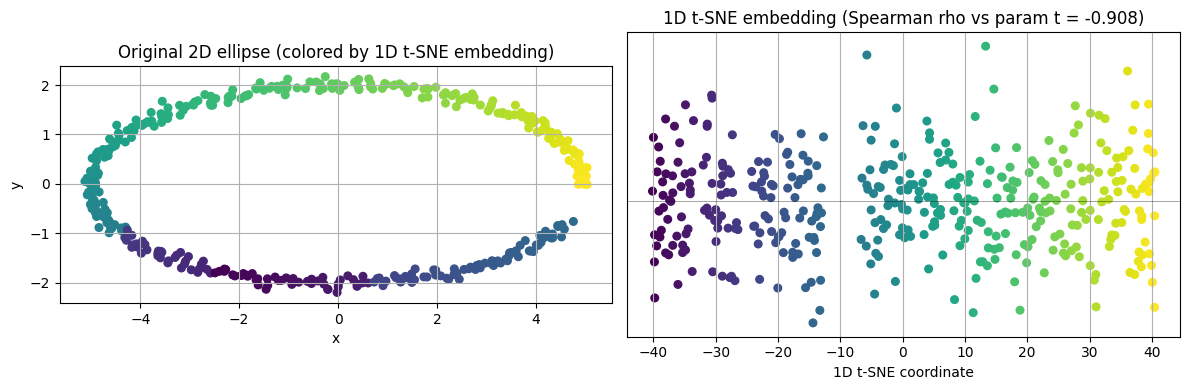

Spearman rank correlation between parameter t (ellipse angle) and 1D embedding: rho = -0.9076, p = 4.05e-152


In [27]:
# t-SNE mapping from 2D -> 1D: oval (ellipse) case
# - generate points around an ellipse in 2D (closed curve)
# - run t-SNE with n_components=1
# - plot original 2D scatter and the 1D embedding (points along a horizontal axis),
#   coloring points by their 1D coordinate to show neighborhood preservation / unfolding.
#
# Requirements: numpy, matplotlib, scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.stats import spearmanr

np.random.seed(2)

# Generate ellipse points (parametric): x = a*cos(t), y = b*sin(t), plus small radial noise
n = 400
t = np.linspace(0, 2 * np.pi - 0.4, n, endpoint=False)
a, b = 5.0, 2.0  # major/minor radii
X_circle = np.column_stack([a * np.cos(t), b * np.sin(t)])
noise_radial = 0.08
# Add small noise perpendicular to the ellipse (radial jitter)
norms = np.linalg.norm(X_circle, axis=1, keepdims=True)
X = X_circle + noise_radial * np.random.randn(n, 2)

# Run t-SNE to 1D
tsne = TSNE(n_components=1, perplexity=30, max_iter=1000, random_state=0, init='pca')
z = tsne.fit_transform(X).flatten()

# Normalize z to [0,1] for color mapping
z_min, z_max = z.min(), z.max()
z_norm = (z - z_min) / (z_max - z_min + 1e-12)

# Measure how well the circular parameter order correlates with embedded order
# Use circular-to-linear rank correlation: we compare parameter t (unwrap) with z ranks via Spearman.
rho, pval = spearmanr(t, z)

# Plot original 2D ellipse colored by z and the 1D embedding
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(X[:, 0], X[:, 1], c=z_norm, cmap='viridis', s=30)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Original 2D ellipse (colored by 1D t-SNE embedding)')
ax1.grid(True)
ax1.set_aspect('equal', adjustable='box')

# 1D embedding along horizontal axis at y=0; add a tiny vertical jitter for visibility
y_jitter = 0.01 * np.random.randn(n)
ax2.scatter(z, y_jitter, c=z_norm, cmap='viridis', s=30)
ax2.axhline(0, color='k', linewidth=0.5, alpha=0.5)
ax2.set_yticks([])
ax2.set_xlabel('1D t-SNE coordinate')
ax2.set_title(f'1D t-SNE embedding (Spearman rho vs param t = {rho:.3f})')
ax2.grid(True, axis='x')

plt.tight_layout()
plt.show()

print(f"Spearman rank correlation between parameter t (ellipse angle) and 1D embedding: rho = {rho:.4f}, p = {pval:.3g}")

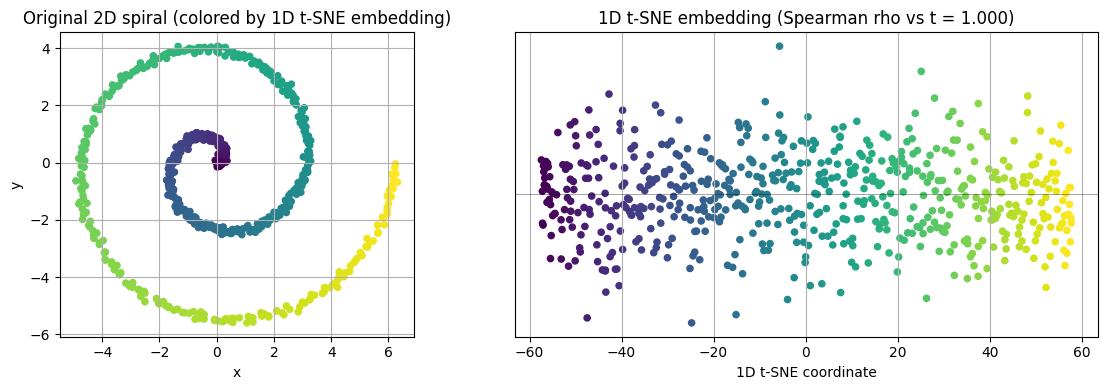

Spearman rank correlation between spiral parameter t and 1D embedding: rho = 0.9999, p = 0


In [20]:
# t-SNE mapping from 2D -> 1D: helix-like (spiral) curve case
# - generate points along a 2D spiral (a 2D analog of a helix)
# - run t-SNE with n_components=1
# - plot original 2D scatter and the 1D embedding (points along a horizontal axis),
#   coloring points by their 1D coordinate to show neighborhood preservation / unfolding.
#
# Requirements: numpy, matplotlib, scikit-learn
# If TSNE errors about parameter names, use max_iter instead of n_iter as shown.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.stats import spearmanr

np.random.seed(3)

# Generate a 2D spiral (a planar helix-like curve)
n = 600
t = np.linspace(0, 4 * np.pi, n)            # parameter along the spiral (4 turns)
a = 0.5                                     # controls spacing between turns
r = a * t                                   # radius grows with t
X_spiral = np.column_stack([r * np.cos(t), r * np.sin(t)])
# add small radial noise so it's not perfectly 1D
noise_scale = 0.08
X = X_spiral + noise_scale * np.random.randn(n, 2)

# Run t-SNE to 1D
# Note: use max_iter if your sklearn requires it
tsne = TSNE(n_components=1, perplexity=30, max_iter=1000, random_state=0, init='pca')
z = tsne.fit_transform(X).flatten()

# Normalize z to [0,1] for color mapping
z_min, z_max = z.min(), z.max()
z_norm = (z - z_min) / (z_max - z_min + 1e-12)

# Measure how well the spiral parameter t correlates with embedded order
rho, pval = spearmanr(t, z)

# Plot original 2D spiral colored by z and the 1D embedding
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(X[:, 0], X[:, 1], c=z_norm, cmap='viridis', s=20)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Original 2D spiral (colored by 1D t-SNE embedding)')
ax1.grid(True)
ax1.set_aspect('equal', adjustable='box')

# 1D embedding along horizontal axis at y=0; add a tiny vertical jitter for visibility
y_jitter = 0.01 * np.random.randn(n)
ax2.scatter(z, y_jitter, c=z_norm, cmap='viridis', s=20)
ax2.axhline(0, color='k', linewidth=0.5, alpha=0.5)
ax2.set_yticks([])
ax2.set_xlabel('1D t-SNE coordinate')
ax2.set_title(f'1D t-SNE embedding (Spearman rho vs t = {rho:.3f})')
ax2.grid(True, axis='x')

plt.tight_layout()
plt.show()

print(f"Spearman rank correlation between spiral parameter t and 1D embedding: rho = {rho:.4f}, p = {pval:.3g}")

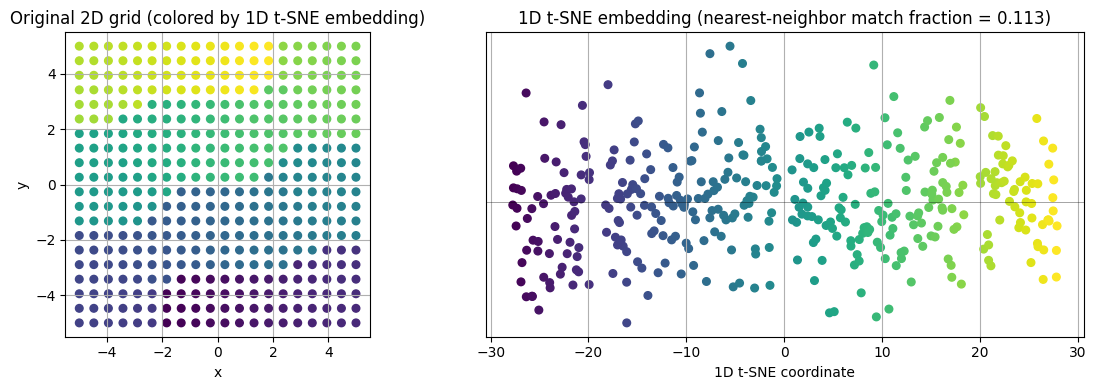

Nearest-neighbor match fraction (1D nearest == 2D nearest): 0.113
Interpretation: values near 1.0 mean very good local-preservation; values near 0 mean poor preservation.


In [22]:
# t-SNE mapping from 2D -> 1D: regular grid case
# - generate a 2D grid of points (all intersections)
# - run t-SNE with n_components=1
# - plot original 2D grid and the 1D embedding (points along a horizontal axis),
#   coloring points by their 1D coordinate to show neighborhood preservation (or failure)
#
# Requirements: numpy, matplotlib, scikit-learn
# If your sklearn uses max_iter instead of n_iter, this uses max_iter.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.stats import spearmanr

np.random.seed(4)

# Generate a regular 2D grid of points
nx, ny = 20, 20            # grid size (nx * ny points)
xs = np.linspace(-5, 5, nx)
ys = np.linspace(-5, 5, ny)
X_grid = np.array([[x, y] for x in xs for y in ys])  # shape (nx*ny, 2)

# Optionally add tiny jitter so points are not perfectly collinear in plotting (not necessary)
jitter = 0.0
X = X_grid + jitter * np.random.randn(X_grid.shape[0], 2)

# Run t-SNE to 1D
tsne = TSNE(n_components=1, perplexity=30, max_iter=1000, random_state=0, init='pca')
z = tsne.fit_transform(X).flatten()

# Normalize z to [0,1] for color mapping
z_min, z_max = z.min(), z.max()
z_norm = (z - z_min) / (z_max - z_min + 1e-12)

# As there's no single natural 1D parameter for a grid, we can compare
# how well local neighborhoods are preserved by checking a trustworthiness-like measure:
# Here we compute Spearman correlation between rank of distances in X and ranks in z
# For performance, compute correlation between distances to nearest neighbor indices aggregated.
from sklearn.metrics import pairwise_distances
D = pairwise_distances(X)                 # full distance matrix (N x N)
# For a simple diagnostic, compute for each point the index of its nearest neighbor in X (excluding itself)
N = X.shape[0]
nearest_in_X = np.argsort(D, axis=1)[:, 1]  # nearest neighbor indices by Euclidean distance
# Now compute order in z and nearest neighbor in z (1D)
order_z = np.argsort(z)
rank_z = np.empty_like(order_z)
rank_z[order_z] = np.arange(N)
nearest_in_z = np.argsort(np.abs(z[:, None] - z[None, :]), axis=1)[:, 1]

# Compute fraction of points whose nearest neighbor in 1D matches nearest neighbor in original 2D
match_fraction = np.mean(nearest_in_X == nearest_in_z)

# Plot original 2D grid colored by z and the 1D embedding
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(X[:, 0], X[:, 1], c=z_norm, cmap='viridis', s=30)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Original 2D grid (colored by 1D t-SNE embedding)')
ax1.grid(True)
ax1.set_aspect('equal', adjustable='box')

# 1D embedding along horizontal axis at y=0; add a small vertical jitter for visibility
y_jitter = 0.01 * np.random.randn(X.shape[0])
ax2.scatter(z, y_jitter, c=z_norm, cmap='viridis', s=30)
ax2.axhline(0, color='k', linewidth=0.5, alpha=0.5)
ax2.set_yticks([])
ax2.set_xlabel('1D t-SNE coordinate')
ax2.set_title(f'1D t-SNE embedding (nearest-neighbor match fraction = {match_fraction:.3f})')
ax2.grid(True, axis='x')

plt.tight_layout()
plt.show()

print(f"Nearest-neighbor match fraction (1D nearest == 2D nearest): {match_fraction:.3f}")
print("Interpretation: values near 1.0 mean very good local-preservation; values near 0 mean poor preservation.")